# Image Imputer - ResNet-18

## General Pipeline

1. Input: Image + Model  

2. Imputer: defines players (patches / SLIC / masks) and for given coalition masks image, implements value function (payoff of a coalition)  

3. Game: batched model calls to collect payoff for different coalitions (defined as set of players and a value function)  

4. Approximator: takes game and runs sampling strategy to estimate the shapley values or interactions  

5. Output: interaction values (score per player, telling how much each region contributed to the prediction)

## Imputer

Implement the core imputer(s) as a subclass of `shapiq.imputer.base.Imputer`. It must:

- Accept an image (numpy array, PIL image, or tensor) and a user-supplied `model` callable that returns predictions for a batch of images.
- Define *players* via a pluggable strategy — at minimum supporting:
  - **Fixed-grid patches** for ViT-style models (configurable grid size).
  - **Superpixels** via at least one algorithm from `skimage.segmentation` (SLIC is a sensible default).
  - **Custom player masks** provided by the user (arbitrary binary masks per player).
- Provide *masking strategies* as a pluggable component — at minimum supporting:
  - **Mean-color** imputation (current baseline in `_resnet_setup.py`).
  - **Zero / baseline-value** imputation.
  - **Blur** imputation (Gaussian blur of the masked region).
  - **Attention masking** for transformer-based models (using `bool_masked_pos` or equivalent, see `_vit_setup.py`).
  - Students should research further mechanisms (e.g. inpainting, learned imputers, dataset-mean baselines) and include at least one that goes beyond the above.
- Implement `value_function(coalitions: np.ndarray) -> np.ndarray` efficiently — **coalitions must be evaluated in batches** through a single model call where possible, not one coalition at a time.
- Work with **PyTorch and JAX/Flax models** via the user-supplied callable. The imputer itself should not import torch or jax at module level; only the player/masking strategies that actually need them should.
- Integrate with the existing explainer pipeline so that `Explainer(model=vit_model, data=image, imputer=ImageImputer(...))` works end-to-end.


In [2]:
import numpy as np
from abc import ABC, abstractmethod

class PlayerStrategy(ABC):
    """Defines how the image is split into n_players regions/players."""
    
    @abstractmethod
    def get_masks(self, image: np.ndarray) -> np.ndarray:
        """
        Returns binary masks for each player/region.
        
        Returns:
            masks: shape (n_players, H, W) — masks[i] == 1 where player i can see the image, 0 otherwise.
        """
        ...
    
    @property
    @abstractmethod
    def n_players(self) -> int:
        """Returns the number of players/regions."""
        ...


class SuperpixelStrategy(PlayerStrategy):
    """Splits the image into superpixels using SLIC."""
    
    def __init__(self, n_segments: int = 10):
        self.n_segments = n_segments
    
    def get_masks(self, image: np.ndarray) -> np.ndarray: # used code form shapiq_games._setup._resnet_setup
        """Run SLIC and return the superpixel mask.

        Runs SLIC and retrying with randomized values if the number of superpixels does not match
        the desired number.

        Args:
            image: The image

        Returns:
            The superpixel mask

        """
        from skimage.segmentation import slic
        
        # run slic for first time
        superpixels = slic(image, n_segments=self.n_segments, start_label=1, slic_zero=True)
        n_superpixels = len(np.unique(superpixels))

        # retry with increasing segments
        if n_superpixels < self.n_segments:
            iteration, n_segments_iter = 0, self.n_segments
            while iteration < 20 and n_superpixels < self.n_segments:
                n_segments_iter += 1
                superpixels = slic(image, n_segments=n_segments_iter, start_label=1, slic_zero=True)
                n_superpixels = len(np.unique(superpixels))
                iteration += 1

        # fallback to clipping the last superpixels
        if n_superpixels >= self.n_segments:
            # clip the superpixels to the desired number of segments
            superpixels = np.clip(superpixels, a_min=1, a_max=self.n_segments)
            n_superpixels = self.n_segments
            
        players = np.arange(1, self.n_segments + 1).reshape(-1, 1, 1) # shape (n_players, 1, 1), reshape for broadcasting
        masks = (superpixels == players) # shape (n_players, H, W)
        
        return masks
    
    @property
    def n_players(self) -> int:
        return self.n_segments

In [3]:
class MaskingStrategy(ABC):
    """Defines how the masked pixels are imputed/replaced."""
    
    @abstractmethod
    def apply(self, image: np.ndarray, player_masks: np.ndarray, coalition: np.ndarray) -> np.ndarray:
        """
        Args:
            image:        (H, W, C) original image
            player_masks: (n_players, H, W) boolean masks per player
            coalition:    (n_coalitions, n_players) boolean array
        
        Returns:
            masked_images: (n_coalitions, H, W, C)
        """
        ...


class MeanColorMasking(MaskingStrategy):
    """Imputes the masked pixels with the mean color of the entire image."""
    
    def apply(self, image: np.ndarray, player_masks: np.ndarray, coalition: np.ndarray) -> np.ndarray:
        n_coalitions = coalition.shape[0]
        H, W, _ = image.shape
        
        masked_images = np.stack([image] * n_coalitions, axis=0) # shape (n_coalitions, H, W, C)
        
        mask = np.zeros((n_coalitions, H, W), dtype=bool)
        for i, coal in enumerate(coalition):
            for j, is_present in enumerate(coal):
                if not is_present:
                    mask[i] |= player_masks[j]
                    
        masked_images[mask] = image.mean(axis=(0, 1))
        
        return masked_images


class ZeroMasking(MaskingStrategy):
    """Imputes the masked pixels with zeros (or a configurable value)."""
    
    def __init__(self, value: float = 0.0):
        self.value = value
    
    def apply(self, image: np.ndarray, player_masks: np.ndarray, coalition: np.ndarray) -> np.ndarray:
        n_coalitions = coalition.shape[0]
        H, W, _ = image.shape
        
        masked_images = np.stack([image] * n_coalitions, axis=0) # shape (n_coalitions, H, W, C)
        
        mask = np.zeros((n_coalitions, H, W), dtype=bool)
        for i, coal in enumerate(coalition):
            for j, is_present in enumerate(coal):
                if not is_present:
                    mask[i] |= player_masks[j]
                    
        masked_images[mask] = self.value
        
        return masked_images

### Testing implemented Masking and segmentation strategies

! Test only works with even number of segments, because of defined dummy coalitions

Image shape: (600, 600, 3)
Player masks shape: (14, 600, 600)
Masks dtype: bool
Every pixel covered: True
No pixel in two players: True


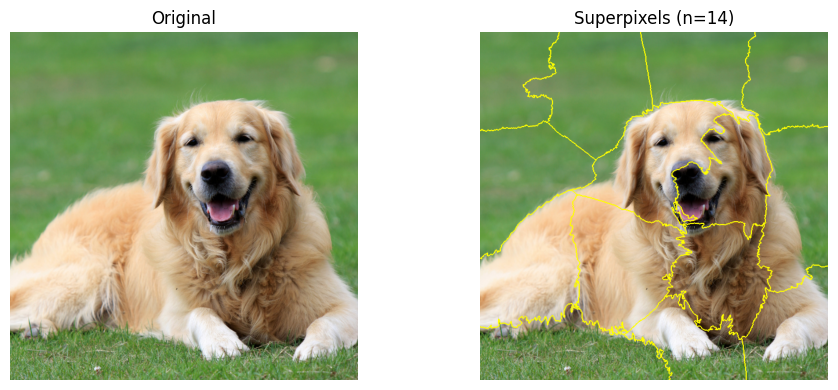


ZeroMasking output shape: (3, 600, 600, 3)
All-present coalition unchanged: True
All-absent coalition is zeros:   True


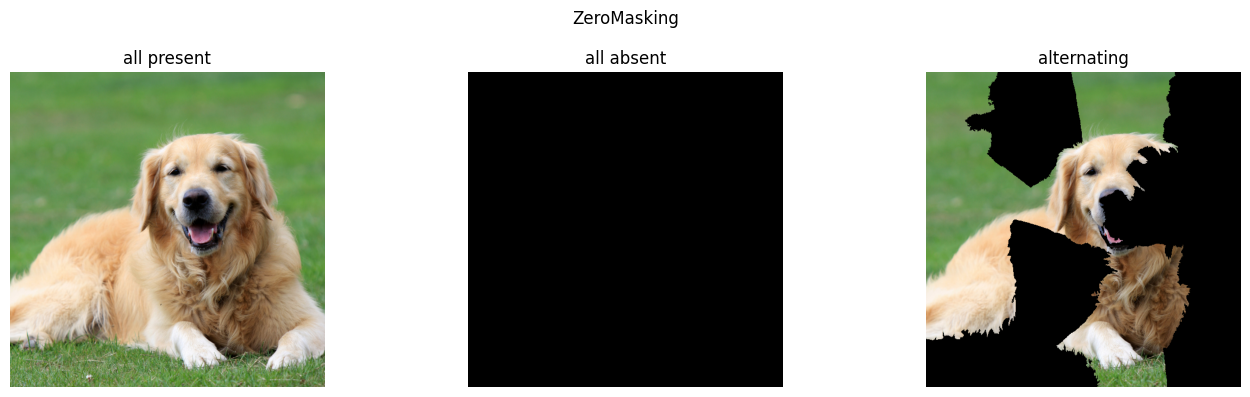


MeanColorMasking output shape: (3, 600, 600, 3)
All-present coalition unchanged: True
All-absent coalition is mean color: False


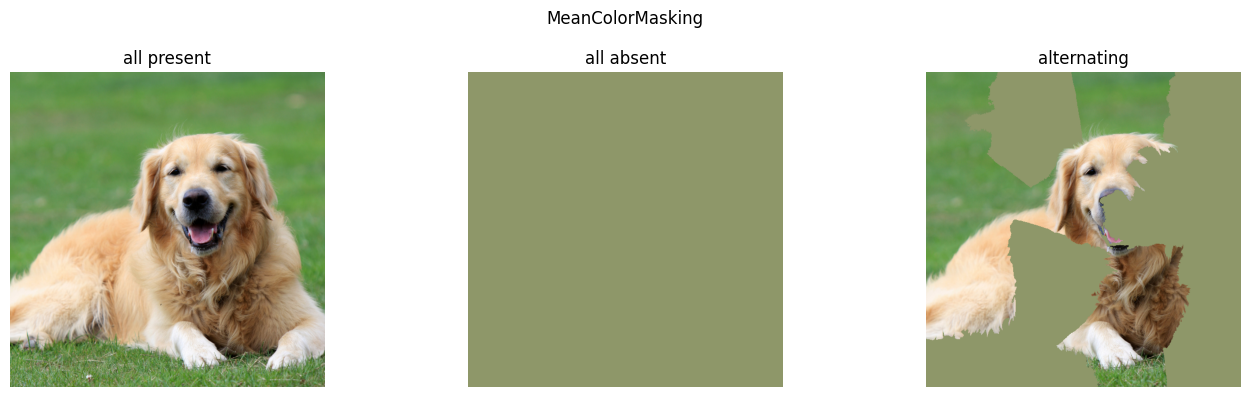

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
from skimage.segmentation import mark_boundaries

# --- load a test image ---
img = "dog.png"
image = np.array(Image.open(img).convert("RGB"))
print(f"Image shape: {image.shape}")

# --- test SuperpixelStrategy ---
strategy = SuperpixelStrategy(n_segments=14)
masks = strategy.get_masks(image)
print(f"Player masks shape: {masks.shape}")          # expected: (10, H, W)
print(f"Masks dtype: {masks.dtype}")                 # expected: bool
print(f"Every pixel covered: {masks.any(axis=0).all()}")  # expected: True
print(f"No pixel in two players: {(masks.sum(axis=0) == 1).all()}")  # expected: True

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(mark_boundaries(image, masks.argmax(axis=0) + 1))
axes[1].set_title(f"Superpixels (n={strategy.n_players})")
axes[1].axis("off")
plt.tight_layout()
plt.show()


# --- dummy coalitions ---
n_players = strategy.n_players
coalitions = np.array([
    [True]  * n_players,   # all present  -> image unchanged
    [False] * n_players,   # all absent   -> fully masked
    [True, False] * (n_players // 2),  # alternating
])

labels = ["all present", "all absent", "alternating"]

# --- visualize masking strategies ---
for MaskingClass, title in [(ZeroMasking, "ZeroMasking"), (MeanColorMasking, "MeanColorMasking")]:
    masking = MaskingClass()
    result = masking.apply(image, masks, coalitions)
    
    print(f"\n{title} output shape: {result.shape}")  # expected: (3, H, W, C)
    print(f"All-present coalition unchanged: {np.array_equal(result[0], image)}")  # True
    if title == "ZeroMasking":
        print(f"All-absent coalition is zeros:   {(result[1] == 0.0).all()}")           # True
    elif title == "MeanColorMasking":
        mean_color = image.mean(axis=(0, 1))
        print(f"All-absent coalition is mean color: {np.allclose(result[1], mean_color)}")  # True

    fig, axes = plt.subplots(1, len(coalitions), figsize=(14, 4))
    fig.suptitle(title)
    for ax, masked_img, label in zip(axes, result, labels):
        ax.imshow(masked_img.astype(np.uint8))
        ax.set_title(label)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [5]:
from shapiq.imputer.base import Imputer

class ImageImputer(Imputer):
    """
    Imputer for images: creates masked versions of the input image based on player coalitions and returns model predictions.    
    
    """
    
    def __init__(
        self,
        model,           
        image: np.ndarray, 
        player_strategy: PlayerStrategy,
        masking_strategy: MaskingStrategy,
        normalize: bool = True
    ):
        dummy_data = np.zeros((1, player_strategy.n_players)) # mocking data input to match Imputers expected input shape
        super().__init__(model=model, data=dummy_data)
        
        self.image = image
        self.player_strategy = player_strategy
        self.player_masks = player_strategy.get_masks(image)
        self.masking_strategy = masking_strategy
    
        self.empty_prediction = self.calc_empty_prediction()
        if normalize:
            self.normalization_value = self.empty_prediction
        
    
    def value_function(self, coalitions: np.ndarray) -> np.ndarray:
        """
        Calculates the value function for a batch of coalitions.
        
        Args:
            coalitions: (n_coalitions, n_players) boolean array
            
        Returns:
            (n_coalitions,) float array with model-Predictions
        
        """
        masked_images = self.masking_strategy.apply(self.image, self.player_masks, coalitions) # shape (n_coalitions, H, W, C)
        predictions = self.model(masked_images)
        
        return np.array(predictions).squeeze()
    
    
    def calc_empty_prediction(self) -> float:
        """Runs the model on empty data points (all features missing) to get the empty prediction.

        Returns:
            The empty prediction of the model provided only missing features.

        """
        empty_image = self.masking_strategy.apply(self.image, self.player_masks, np.array([[False] * self.player_strategy.n_players]))[0]
        prediction = self.model(empty_image[np.newaxis]) # batch: shape (1, H, W, C)

        return float(prediction[0])

### Imputer test with ResNet-18 model loaded externally

In [6]:
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

# --- load test image ---
img = "dog.png"
image = np.array(Image.open(img).convert("RGB").resize((224, 224)))
print(f"Image shape: {image.shape}")  # expected: (224, 224, 3)

# --- load resnet-18 ---
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.eval()

preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# get predicted class of original image
original_tensor = preprocess(Image.fromarray(image)).unsqueeze(0)
with torch.no_grad():
    predicted_class = resnet(original_tensor).argmax(dim=1).item()

def model(batch: np.ndarray) -> np.ndarray:
    """Wraps ResNet-18 to accept (N, H, W, C) numpy arrays and return (N,) predictions."""
    tensors = torch.stack([preprocess(Image.fromarray(img.astype(np.uint8))) for img in batch])
    with torch.no_grad():
        logits = resnet(tensors)  # (N, 1000)
    return logits[:, predicted_class].numpy()  # (N,) — only the relevant class

# --- setup imputer ---
strategy = SuperpixelStrategy(n_segments=10)
masking = ZeroMasking()

imputer = ImageImputer(
    model=model,
    image=image,
    player_strategy=strategy,
    masking_strategy=masking,
    normalize=True,
)

print(f"n_players: {imputer.n_players}")               # expected: 10
print(f"empty_prediction: {imputer.empty_prediction}") # some float

# --- test value_function directly ---
coalitions = np.array([
    [True]  * strategy.n_players,   # all present
    [False] * strategy.n_players,   # all absent  -> should equal empty_prediction
    [True, False] * (strategy.n_players // 2),
])

output = imputer.value_function(coalitions)
print(f"\nvalue_function output shape: {output.shape}")  # expected: (3,)
print(f"value_function outputs: {output}")  # some floats
print(f"All-absent matches empty_prediction: {np.allclose(output[1], imputer.empty_prediction)}")

# --- test via shapiq __call__ ---
output_call = imputer(coalitions)
print(f"\n__call__ output shape: {output_call.shape}")
print(f"All-absent coalition value after normalization: {output_call[1]}")  # expected: ~0.0

Image shape: (224, 224, 3)
n_players: 10
empty_prediction: -0.3427250385284424

value_function output shape: (3,)
value_function outputs: [14.219813   -0.34272522 13.316451  ]
All-absent matches empty_prediction: True

__call__ output shape: (3,)
All-absent coalition value after normalization: -1.7881393432617188e-07


### Directly use Imputer as Game for testing:

In [7]:
import shapiq

approximator = shapiq.SHAPIQ(n=imputer.n_players, max_order=2, index="k-SII")
interaction_values = approximator.approximate(budget=64, game=imputer)
print(interaction_values)

InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=True, estimation_budget=64,
    n_players=10, baseline_value=-5.960464477539063e-08,
    Top 10 interactions:
        (4, 9): 19.554582148566432
        (3, 5): 17.27774612106168
        (9,): 16.570208529346786
        (2, 7): 12.972997718455819
        (4,): 12.387656957126662
        (2, 3): 11.961759697021426
        (5, 6): -10.515415627437436
        (2, 9): -15.031277750407487
        (2, 4): -17.815490192588687
        (1, 5): -18.65156110067559
)


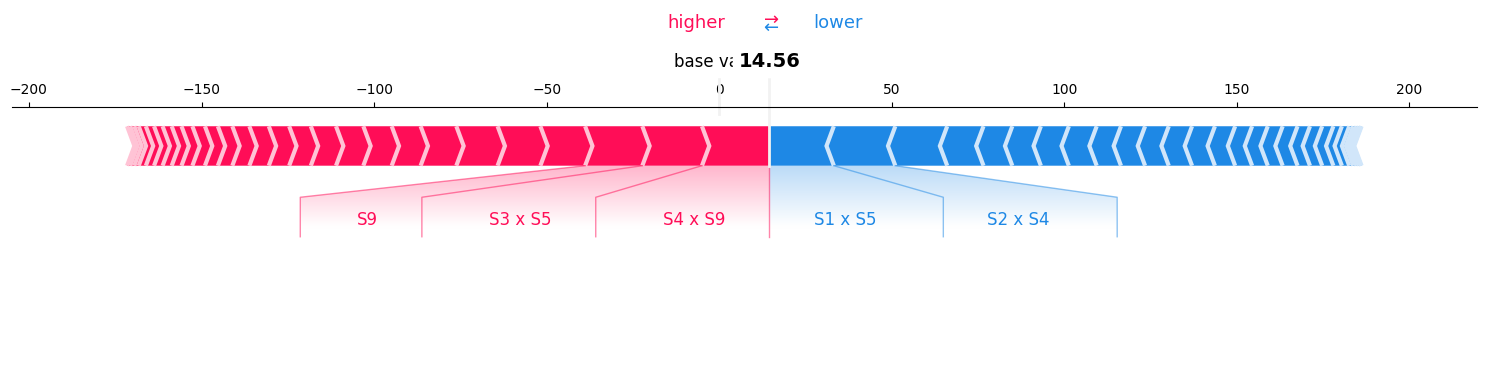

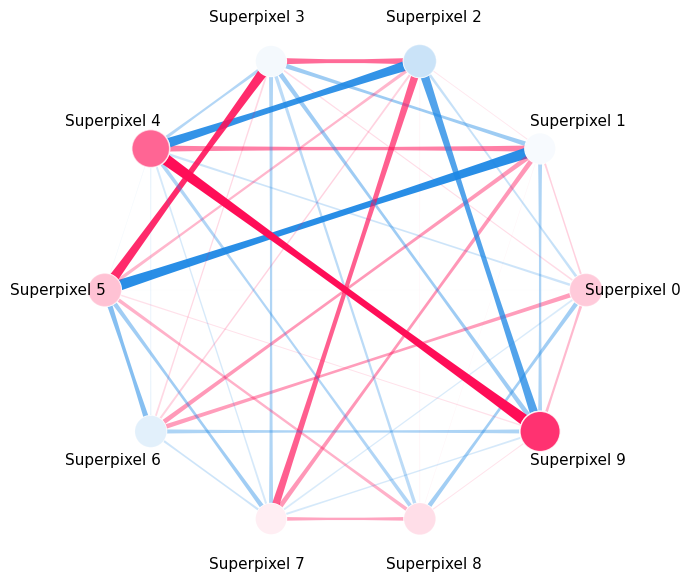

In [8]:
superpixels = [f"Superpixel {i}" for i in range(imputer.n_players)]
interaction_values.plot_force(feature_names=superpixels)
interaction_values.plot_network(feature_names=superpixels)

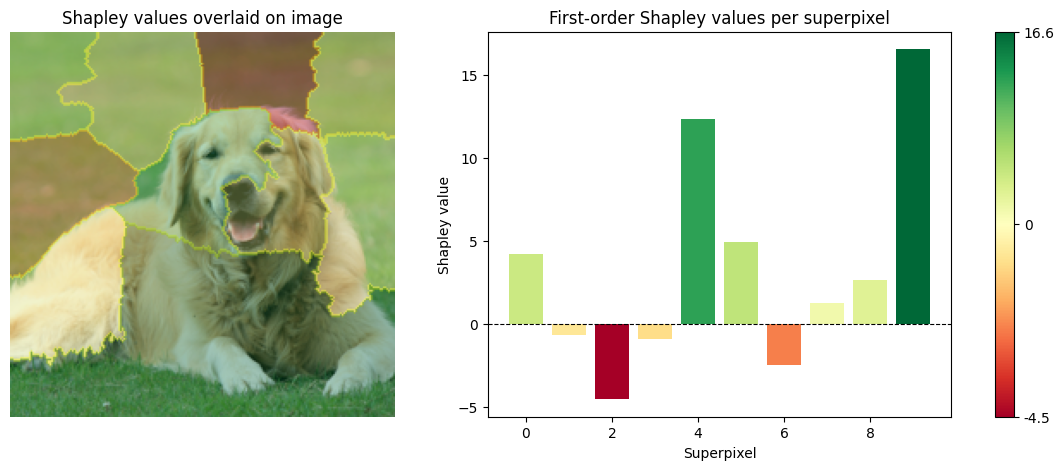

In [9]:
# heat map plot:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from skimage.segmentation import mark_boundaries

# get first-order values
first_order = interaction_values.get_n_order_values(1)

# build heatmap
heatmap = np.zeros(image.shape[:2])
for i in range(strategy.n_players):
    heatmap[imputer.player_masks[i]] = first_order[i]

# shared colormap and norm
cmap = cm.RdYlGn
norm = mcolors.TwoSlopeNorm(vmin=heatmap.min(), vcenter=0, vmax=heatmap.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- heatmap ---
axes[0].imshow(image)
hm = axes[0].imshow(heatmap, alpha=0.5, cmap=cmap, norm=norm)
axes[0].imshow(mark_boundaries(image, imputer.player_masks.argmax(axis=0) + 1), alpha=0.3)
axes[0].set_title("Shapley values overlaid on image")
axes[0].axis("off")

# --- bar plot colored like heatmap ---
bar_colors = [cmap(norm(v)) for v in first_order]
axes[1].bar(range(strategy.n_players), first_order, color=bar_colors)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Superpixel")
axes[1].set_ylabel("Shapley value")
axes[1].set_title("First-order Shapley values per superpixel")

# colorbar for bar plot
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.04)
cbar.set_ticks([heatmap.min(), 0, heatmap.max()])
cbar.set_ticklabels([f"{heatmap.min():.1f}", "0", f"{heatmap.max():.1f}"])

plt.show()

## Explainer

Hook the imputer into shapiq's explainer layer, we need:

1. `shapiq.Explainer(model=vit_model, data=image, imputer=ImageImputer(...))` working end-to-end.
2. Running the whole pipeline as a cooperative **Game** (since `ImageImputer` already subclasses `shapiq.Game` via `Imputer`).

For this MVP we define `ImageExplainer` as a direct subclass of `shapiq.Explainer`. Since it inherits
from `Explainer`, it integrates with the existing pipeline out of the box: same `explain()` API,
same `InteractionValues` output, same approximator infrastructure.

In [18]:
import shapiq
from shapiq.explainer.base import Explainer
from shapiq.explainer.configuration import setup_approximator


class ImageExplainer(Explainer):
    """Explainer for vision models driven by ImageImputer class.

    Treats the (image, model, imputer) triple as a cooperative ``Game`` and delegates to a
    shapiq approximator. The user-supplied ImageImputer class is the value function: it
    masks the image according to a coalition, calls the model, and returns the payoff.
    """

    def __init__(
        self,
        model,
        data,
        imputer,
        *,
        index: str = "k-SII",
        max_order: int = 2,
        random_state: int | None = None,
        class_index: int | None = None,  # accepted for API compatibility; unused in MVP
        **_: object,
    ) -> None:
        self.model = model
        self._model_class = type(model).__name__
        self._shapiq_predict_function = lambda m, d: m(d)
        self._model_type = "image"
        self._data = data
        self._index = index
        self._max_order = max_order
        self._imputer = imputer
        self._approximator = setup_approximator(
            approximator="auto",
            index=index,
            max_order=max_order,
            n_players=imputer.n_players,
            random_state=random_state,
        )
        self._exact_computer = None

    def explain_function(self, x=None, *, budget: int = 64, random_state: int | None = None, **_):
        if random_state is not None:
            self.set_random_state(random_state=random_state)
        ivs = self.approximator.approximate(budget=budget, game=self.imputer)
        ivs.baseline_value = self.imputer.empty_prediction
        return ivs

    @property
    def baseline_value(self) -> float:
        return self.imputer.empty_prediction

### End-to-end with `ImageExplainer`

`ImageExplainer` is a `shapiq.Explainer` subclass, so calling it directly integrates into the
existing explainer pipeline. It wires the `ImageImputer` game to a shapiq approximator and
produces standard `InteractionValues` output.

In [19]:
image_imputer = ImageImputer(
    model=model,
    image=image,
    player_strategy=SuperpixelStrategy(n_segments=10),
    masking_strategy=MeanColorMasking(),
    normalize=True,
)

explainer = ImageExplainer(
    model=model,
    data=image,
    imputer=image_imputer,
    index="k-SII",
    max_order=2,
    random_state=0,
)
print(f"n_players: {explainer.imputer.n_players}")
print(f"baseline_value: {explainer.baseline_value:.4f}")

interaction_values = explainer.explain(budget=64)
print(interaction_values)

n_players: 10
baseline_value: -0.0463
InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=True, estimation_budget=64,
    n_players=10, baseline_value=-0.046250224113464355,
    Top 10 interactions:
        (5,): 12.645003894385525
        (4,): 10.688113708135246
        (1, 5): 7.754255494188085
        (9,): 6.797792233300602
        (8,): 5.983569226556942
        (3, 5): 5.284039466717586
        (5, 8): -5.371099816328072
        (5, 9): -5.736114312953519
        (2, 3): -7.18306792467551
        (4, 5): -11.530659665851076
)


### Execute everything together as a `Game`

The `ImageImputer` already is a cooperative game,it inherits from `shapiq.Game` via
`shapiq.imputer.base.Imputer`. That means we can hand it to `shapiq.AgnosticExplainer`
(the model-agnostic, game-based explainer) and the whole image-explanation pipeline runs
purely through the `Game` abstraction: every coalition is a masking pattern on the image,
every value is a model call.

In [20]:
from shapiq import AgnosticExplainer, Game

assert isinstance(image_imputer, Game), "ImageImputer must be a Game for AgnosticExplainer."

game_explainer = AgnosticExplainer(
    game=image_imputer,
    index="k-SII",
    max_order=2,
    random_state=0,
)
game_interaction_values = game_explainer.explain(budget=64)

print(f"Game name: {image_imputer.game_name}")
print(f"n_players: {image_imputer.n_players}")
print(f"normalization_value (= empty_prediction): {image_imputer.normalization_value:.4f}")
print(game_interaction_values)

Game name: ImageImputer_Imputer_Game
n_players: 10
normalization_value (= empty_prediction): -0.0463
InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=True, estimation_budget=64,
    n_players=10, baseline_value=-1.4454126358032227e-06,
    Top 10 interactions:
        (5,): 12.645003894385525
        (4,): 10.688113708135246
        (1, 5): 7.754255494188085
        (9,): 6.797792233300602
        (8,): 5.983569226556942
        (3, 5): 5.284039466717586
        (5, 8): -5.371099816328072
        (5, 9): -5.736114312953519
        (2, 3): -7.18306792467551
        (4, 5): -11.530659665851076
)
